# Analysis of Population Service Per Station

Motivation: To assess whether suburban sprawl increases the financial burden on AFD by decreasing the number of households served per station.

## Methodology:

1. Extract population data at the census tract level. 
2. For each census tract
    a. locate the closest fire station (used as the primary key)
    b. locate all fire stations contained in the census tract (to keep track of any fire stations which are not the closest station to *any* census tract)
3. For each primary key fire station (see 2a), sum up the total population of each census tract to which it is closest. This is the "Total Population"
4. For each primary key fire station, list all other fire stations contained in each census tract to which it is closest. Count how many stations there are, including the primay. This is the "Number of Stations".
5. The "Total Population / Number of Stations" is the average "Population per Station". This is what is portrayed on the bottom plot.

## Conclusion:

There is a strong correlation between proximity to central Austin and residents-served-per-station. This is most marked between inner- and outer-suburbs, where coverage in outer suburban areas is mostly very sparse, except for a few over-utilized stations (ex: 11401 Escarpment Blvd in SW Austin)

In [1]:
import pandas as pd
import geopandas as gpd

AUSTIN_COUNTIES = {
    "TRAVIS": '453', 
    "HAYS": '209', 
    "WILLIAMSON": '491',
    }

stations = gpd.read_file("../raw_data/fire_stations.geojson")
stations = stations[(stations['FACILITY']=='FIRE STATION')]
stations = stations.to_crs("EPSG:32614")
stations.drop(['CREATED_BY', 'CREATED_DATE', 'MODIFIED_BY', 'MODIFIED_DATE','FACILITY'], axis=1, inplace=True)

census = gpd.read_file("../raw_data/tl_2023_48_tract.shp")
census = census[census["COUNTYFP"].isin(AUSTIN_COUNTIES.values())]

census_pop = pd.read_csv("../raw_data/census_population.csv", dtype={"tract": str, "county": str})
census_pop = census_pop[census_pop["county"].isin(AUSTIN_COUNTIES.values())]

census = census.merge(census_pop[['Total population','tract','county']], left_on=["TRACTCE", "COUNTYFP"], right_on=["tract","county"], how="left")
census.drop(["STATEFP","tract","county","AWATER","NAME"], axis=1, inplace=True)
census = census.to_crs("EPSG:32614")
census['centroid'] = census['geometry'].centroid

In [2]:
# Find nearest station to each census tract centroid
df = census.sjoin_nearest(stations[['OBJECTID','JURISDICTION', 'FIRESTATIONS_ID', 'ADDRESS', 'NAME',
       'STATION_NUMBER', 'TYPE', 'STATUS','Y_COORDINATE', 'X_COORDINATE','geometry']], rsuffix="stat", lsuffix="tract")
df.head()

,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAMELSAD,MTFCC,FUNCSTAT,ALAND,INTPTLAT,INTPTLON,...,OBJECTID,JURISDICTION,FIRESTATIONS_ID,ADDRESS,NAME,STATION_NUMBER,TYPE,STATUS,Y_COORDINATE,X_COORDINATE
0,453,040700,48453040700,1400000US48453040700,Census Tract 407,G5020,S,1971513,+30.3718046,-097.7148275,...,57,AUSTIN,33,"8989 Research Blvd, Austin, TX 78758",FS0008,8,10.0,AFD BUILT,10108845.0,3119662.0
1,453,041900,48453041900,1400000US48453041900,Census Tract 419,G5020,S,2656097,+30.3924913,-097.6904457,...,53,AUSTIN,50,"1021 W Braker Ln, Austin, TX 78758",FS0030,30,10.0,AFD BUILT,10113279.0,3129234.0
2,453,041100,48453041100,1400000US48453041100,Census Tract 411,G5020,S,1439764,+30.3851014,-097.6791969,...,53,AUSTIN,50,"1021 W Braker Ln, Austin, TX 78758",FS0030,30,10.0,AFD BUILT,10113279.0,3129234.0
3,453,036700,48453036700,1400000US48453036700,Census Tract 367,G5020,S,7448619,+30.1956961,-097.9036899,...,37,AUSTIN,83,"11401 Escarpment Blvd, Austin, TX 78739",FS0043,43,11.0,AFD BUILT,10038684.0,3066128.0
4,453,044000,48453044000,1400000US48453044000,Census Tract 440,G5020,S,2344439,+30.3986848,-097.6632231,...,148,AUSTIN,82,"12711 Harrisglenn Dr, Austin, TX 78753",FS0040,40,11.0,AFD BUILT,10119188.0,3141415.0


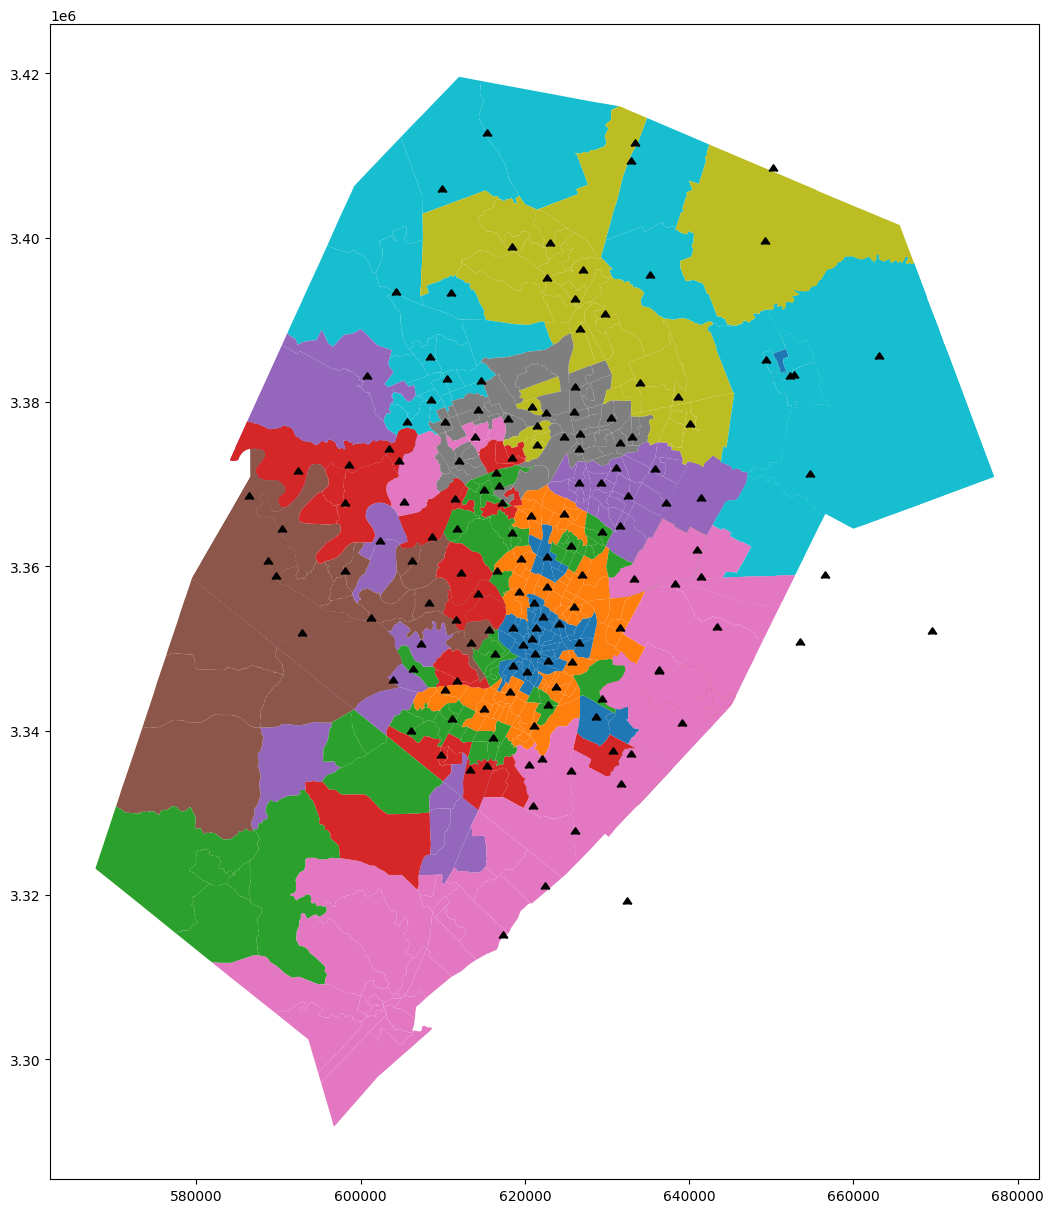

In [3]:
# Plot of Stations overlaid on census tracts colored by sharing the same nearest station.

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

fig.set_size_inches(20,15)

df.plot(column="NAME", ax=ax)

stations.plot(ax=ax, legend="NAME", color="black", marker=10)

plt.show()

In [ ]:
# Some stations are not geometric neighbors to any census tract.
# So, find the stations inside each census tract.
#  Aggregate these stations to the df_agg station groups. And take an average of stations per population.

census_containing_stations = gpd.sjoin(census[['TRACTCE','geometry']], stations[['NAME','geometry']], predicate="contains", how="inner")
tract_with_stations = census_containing_stations.groupby("TRACTCE").agg({"NAME": "count"})
tract_with_stations.rename(columns={"NAME": "num contained stations"}, inplace=True)
tract_with_stations['contained stations'] = census_containing_stations.groupby('TRACTCE')['NAME'].apply(list).tolist()

tract_with_stations.head()

df = df.merge(tract_with_stations, left_on="TRACTCE", right_on="TRACTCE", how="left")

,num contained stations,contained stations
TRACTCE,,
000101,1,[FS0019]
000206,1,[FS0012]
000302,1,[FS0009]
000309,1,[FS0014]
000601,1,[FS0003]


In [6]:
# Aggregate df to station level, and append list of contained stations with primary station id.
stations_w_demographics = df.groupby("NAME").agg({"Total population": "sum"})
stations_w_demographics['contained stations'] = df.groupby('NAME')['contained stations'].apply(list).tolist()
# unwrap the list of lists of contained stations into a single list of contained stations per station.
# df['contained stations'] =
stations_w_demographics['contained stations'] = stations_w_demographics['contained stations'].apply(lambda x: [item for sublist in x if isinstance(sublist, list) for item in sublist])
stations_w_demographics['contained stations'] = stations_w_demographics.apply(lambda row: list(set([row.name] + row['contained stations'])), axis=1).tolist()

stations_w_demographics['num contained stations'] = stations_w_demographics['contained stations'].apply(lambda x: len(x) if isinstance(x, list) else 0)
stations_w_demographics['population per station'] = stations_w_demographics.apply(lambda row: row['Total population'] / row['num contained stations'] if row['num contained stations'] > 0 else None, axis=1)

# Merge averages back to stations df.
stations = stations.merge(stations_w_demographics[['population per station']], left_on="NAME", right_index=True, how="left")

stations["X_COORDINATE"] = stations["geometry"].x
stations["Y_COORDINATE"] = stations["geometry"].y

In [7]:
stations.head()

,OBJECTID,FIRESTATIONS_ID,ADDRESS,NAME,STATION_NUMBER,TYPE,STATUS,DEPARTMENT,SECONDARY_FACILITY,JURISDICTION,Y_COORDINATE,X_COORDINATE,RESOURCES,geometry,population per station
0,1,133,"1501 Cottonwood Creek Trail, Cedar Park, TX 78613",FSCP05,CP5,0.0,BUILT,CEDAR PARK,NaN,CEDAR PARK,3.378649e+06,614238.244611,Unknown,POINT (614238.245 3378649.301),9812.0
1,2,134,"301 Industrial Ave, Georgetown, TX 78626",GT001,GT 1,0.0,BUILT,GEORGETOWN,NaN,GEORGETOWN,3.388485e+06,626764.937808,Unknown,POINT (626764.938 3388485.171),17016.0
2,3,135,"1603 Williams Dr, Georgetown, TX 78628",GT002,GT 2,0.0,BUILT,GEORGETOWN,NaN,GEORGETOWN,3.392151e+06,626061.674809,Unknown,POINT (626061.675 3392150.809),11436.0
3,4,136,"5 Texas Dr, Georgetown, TX 78633",GT003,GT 3,0.0,BUILT,GEORGETOWN,NaN,GEORGETOWN,3.398994e+06,623039.803093,Unknown,POINT (623039.803 3398994.491),13414.0
4,5,137,"4200 Airport Rd, Georgetown, TX 78628",GT004,GT 4,0.0,BUILT,GEORGETOWN,NaN,GEORGETOWN,3.395680e+06,627024.268159,Unknown,POINT (627024.268 3395679.867),7241.0


In [ ]:
# Notice that the station in Uhland apparently serves 138,000 people.
# This is trivial and probably because of jurisdictional overlap with residents who are not in the 3-county area of interest.
# More interesting, is 3 of the 4 most utilized stations are outside Austin in the suburbs.
# This could be because of a gap in the data, or because the suburbs have lower investment in fire stations, or because investment has not caught up to population growth.
stations[['ADDRESS','NAME','DEPARTMENT','JURISDICTION','population per station']].sort_values("population per station", ascending=False).head(10)

,ADDRESS,NAME,DEPARTMENT,JURISDICTION,population per station
86,"15 N Old Spanish Trail, Uhland, TX 78640",FS1109,ESD 11,UHLAND,138678.0
36,"11401 Escarpment Blvd, Austin, TX 78739",FS0043,AFD,AUSTIN,50568.0
106,"2301 Kelly Ln, Pflugerville, TX 78660",FS0203,ESD 2,PFLUGERVILLE,44850.0
68,"2811 Oakmont Dr, Round Rock, TX 78665",FSRR7,ROUND ROCK,ROUND ROCK,38783.0
151,"1570 Cypress Creek Road, Cedar Park, TX 78613",FSCP02,CEDAR PARK,CEDAR PARK,38397.0
59,"5811 Nuckols Crossing Rd, Austin, TX 78744",FS0024,AFD,AUSTIN,36522.0
122,"6311 Berkman Dr, Austin, TX 78723",FS0018,AFD,AUSTIN,35646.0
105,"5309 E Riverside Dr, Austin, TX 78741",FS0022,AFD,AUSTIN,35495.0
66,"500 Ralph Ablanedo Dr, Austin, TX 78748",FS0036,AFD,AUSTIN,33862.0
52,"1021 W Braker Ln, Austin, TX 78758",FS0030,AFD,AUSTIN,33618.0


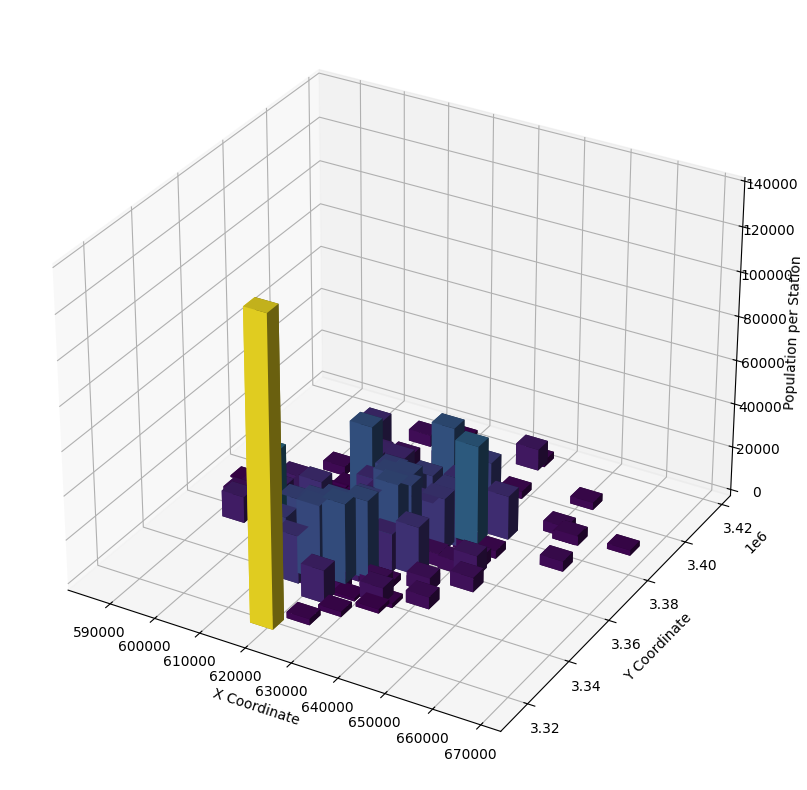

In [9]:
# 3d bar chart of population per station. 

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')
# Filter out NaN values for plotting
plot_data = stations.dropna(subset=['population per station'])

# x, y, bottom, width, depth, top, 
ax.bar3d(
    x=plot_data['X_COORDINATE'],
    y=plot_data['Y_COORDINATE'],
    z=0,
    dx=5000,
    dy=5000,
    dz=plot_data['population per station'],
    color=cm.viridis(plot_data['population per station'] / plot_data['population per station'].max())
)
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Population per Station') 

plt.show()

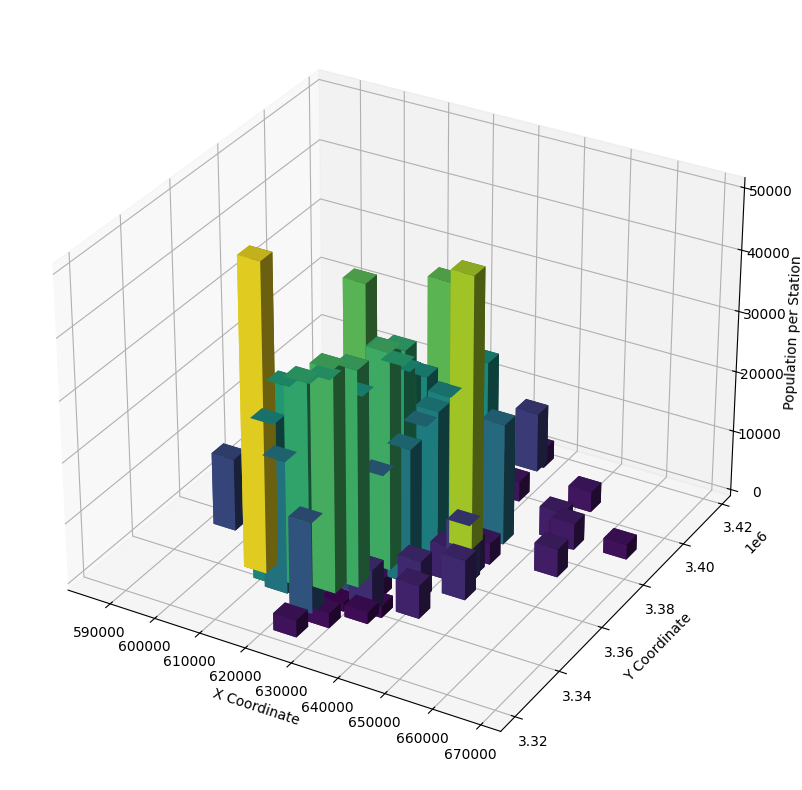

In [10]:
# Same as above plot, but removing outlying Uhland station

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')
# Filter out NaN values for plotting
plot_data = stations.dropna(subset=['population per station'])
plot_data = plot_data[plot_data['population per station'] < 100000]
# x, y, bottom, width, depth, top, 
ax.bar3d(
    x=plot_data['X_COORDINATE'],
    y=plot_data['Y_COORDINATE'],
    z=0,
    dx=5000,
    dy=5000,
    dz=plot_data['population per station'],
    color=cm.viridis(plot_data['population per station'] / plot_data['population per station'].max())
)
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Population per Station') 

plt.show()